# Laboratório 05: Dados Ausentes - Tratamento Univariado e Multivariado
**Disciplina:** Extração e Preparação de Dados (IBM8915)
**Objetivo:** Aprender a usar ferramentas de descarte (`dropna`), preenchimento simples (`fillna`) com estatísticas básicas (univariado) e algoritmos de machine learning via Scikit-Learn (`KNNImputer`) (multivariado) para tratamento assertivo de dados defeituosos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
import warnings
warnings.filterwarnings('ignore')

## Parte 1: Exemplo Guiado - A "Faca" e a "Seringa"
Neste exemplo rápido, usaremos o `.dropna()` (a faca) para amputar o que não tem salvação e o `.fillna()` (a seringa) para curar colunas numéricas e categóricas do nosso DataFrame de pacientes.

In [2]:
# Criando dados fictícios
df_exemplo = pd.DataFrame({
    'Paciente': ['Ana', 'Bruno', 'Carlos', 'Diana', 'Eduardo'],
    'Idade': [25, np.nan, 42, 38, np.nan],         # Numérica
    'Pressao': [120, 125, 130, np.nan, 140],       # Numérica
    'Tipo_Sanguineo': ['O+', 'A-', np.nan, 'O+', np.nan], # Categórica
    'Coluna_Perdida': [np.nan, np.nan, np.nan, np.nan, np.nan] # 100% Nula
})

print("Estado Original:\n", df_exemplo, "\n")

# 1. A Faca: Descartando colunas 100% vazias (axis=1 atinge colunas)
df_exemplo.dropna(axis=1, how='all', inplace=True)

# 2. A Seringa (Numéricos): Preenchendo Idade com a Mediana
mediana_idade = df_exemplo['Idade'].median()
df_exemplo['Idade'].fillna(mediana_idade, inplace=True)

# 3. A Seringa (Categóricos): Preenchendo Tipo Sanguíneo com a Moda
moda_sangue = df_exemplo['Tipo_Sanguineo'].mode()[0] #  pega a primeira moda se houver empate
df_exemplo['Tipo_Sanguineo'].fillna(moda_sangue, inplace=True)

print("Estado Tratado:\n", df_exemplo)

Estado Original:
   Paciente  Idade  Pressao Tipo_Sanguineo  Coluna_Perdida
0      Ana   25.0    120.0             O+             NaN
1    Bruno    NaN    125.0             A-             NaN
2   Carlos   42.0    130.0            NaN             NaN
3    Diana   38.0      NaN             O+             NaN
4  Eduardo    NaN    140.0            NaN             NaN 

Estado Tratado:
   Paciente  Idade  Pressao Tipo_Sanguineo
0      Ana   25.0    120.0             O+
1    Bruno   38.0    125.0             A-
2   Carlos   42.0    130.0             O+
3    Diana   38.0      NaN             O+
4  Eduardo   38.0    140.0             O+


## Parte 2: Exercício Prático (Mão na Massa)
Abaixo geramos um pequeno dataset de imóveis (`df_imoveis`). 
**Sua Tarefa:**
1. Descarte as colunas que possuam **mais de 70%** de valores nulos.
2. Preencha a coluna numérica `Preco` usando a estatística adequada (Média ou Mediana? Dica: Verifique se existem outliers absurdos com `.describe()`).
3. Preencha a coluna categórica `Bairro` com o valor mais comum (Moda).

In [3]:
# NÃO ALTERE ESTE CÓDIGO
np.random.seed(42)
df_imoveis = pd.DataFrame({
    'ID_Imovel': range(1, 101),
    'Bairro': np.random.choice(['Centro', 'Jardins', 'Vila Nova'], 100, p=[0.5, 0.3, 0.2]),
    'Preco': np.append(np.random.normal(300000, 50000, 95), [1500000, 2000000, 2500000, 3000000, 5000000]), # Com outliers milionários
    'Comissao_Corretor_Morta': [np.nan] * 100 # Coluna inútil
})

# Injetando nulos
df_imoveis.loc[np.random.choice(100, 15, replace=False), 'Preco'] = np.nan
df_imoveis.loc[np.random.choice(100, 20, replace=False), 'Bairro'] = np.nan

In [4]:
# RESOLUÇÃO
# Passo 1: Descartar colunas com mais de 70% de nulos (Comissao_Corretor_Morta = 100% nula)
limite_nao_nulos = int(len(df_imoveis) * 0.30)  # manter colunas com >= 30% preenchido
df_imoveis.dropna(axis=1, thresh=limite_nao_nulos, inplace=True)

# Passo 2: 'Preco' tem outliers milionários -> a MEDIANA é mais robusta que a média
print("Outliers em Preco (describe):\n", df_imoveis['Preco'].describe(), "\n")
df_imoveis['Preco'].fillna(df_imoveis['Preco'].median(), inplace=True)

# Passo 3: Preencher 'Bairro' (categórica) com a moda
df_imoveis['Bairro'].fillna(df_imoveis['Bairro'].mode()[0], inplace=True)

print("Nulos restantes:\n", df_imoveis.isna().sum())
df_imoveis.head()


Outliers em Preco (describe):
 count    8.500000e+01
mean     3.897709e+05
std      4.357386e+05
min      2.006216e+05
25%      2.648973e+05
50%      3.048539e+05
75%      3.260971e+05
max      3.000000e+06
Name: Preco, dtype: float64 

Nulos restantes:
 ID_Imovel    0
Bairro       0
Preco        0
dtype: int64


,ID_Imovel,Bairro,Preco
0,1,Centro,304352.353412
1,2,Vila Nova,285049.632477
2,3,Jardins,304588.038827
3,4,Jardins,200621.554270
4,5,Centro,304853.877467


---
## Parte 3: Tratamento Multivariado (Avançado com Scikit-Learn)
Em vez de olhar apenas para a coluna com valores ausentes (univariado), a imputação multivariada utiliza as **outras variáveis** da mesma linha para prever o valor faltante. Vamos usar o `KNNImputer`, que acha os exemplos mais "parecidos" (vizinhos) para inferir a lacuna.

In [5]:
from sklearn.impute import KNNImputer

# Criando um pequeno DataFrame de exemplo
df_knn = pd.DataFrame({
    'Salario': [5000, 5200, 9000, 5100, 8900],
    'Idade': [25, 27, 45, 26, np.nan],  # Alguém esqueceu a idade do último funcionário
    'Tempo_Empresa': [1, 2, 15, 1, 14]
})
print("Antes da Imputação (KNN):\n", df_knn, "\n")

# O KNNImputer substitui o valor ausente usando a média dos k vizinhos mais próximos
imputador_knn = KNNImputer(n_neighbors=2)
df_imputado_numpy = imputador_knn.fit_transform(df_knn)

# O Scikit-Learn retorna um array NumPy! Precisamos recriar o DataFrame
df_knn_tratado = pd.DataFrame(df_imputado_numpy, columns=df_knn.columns)
print("Após a Imputação (KNN):\n", df_knn_tratado)

Antes da Imputação (KNN):
    Salario  Idade  Tempo_Empresa
0     5000   25.0              1
1     5200   27.0              2
2     9000   45.0             15
3     5100   26.0              1
4     8900    NaN             14 

Após a Imputação (KNN):
    Salario  Idade  Tempo_Empresa
0   5000.0   25.0            1.0
1   5200.0   27.0            2.0
2   9000.0   45.0           15.0
3   5100.0   26.0            1.0
4   8900.0   36.0           14.0


### Exercício Prático: KNNImputer
Lembra da coluna `Preco` do nosso dataset `df_imoveis` (na Parte 2)? Se apenas preenchermos com a mediana global, ignoramos se a casa é uma mansão gigante ou um estúdio diminuto.
Vamos preencher o Preco agora de forma inteligente, usando a correlação com as variáveis numéricas fictícias adicionadas: `Metragem` e `Numero_Quartos`.

In [6]:
# NÃO ALTERE ESTE CÓDIGO - Base numérica para imputação multivariada (KNN)
# Preço correlacionado com Metragem e Numero_Quartos
np.random.seed(7)
df_imoveis_knn = pd.DataFrame({
    'ID_Imovel': range(1, 101),
    'Preco': np.append(np.random.normal(300000, 50000, 95),
                       [1500000, 2000000, 2500000, 3000000, 5000000])
})
df_imoveis_knn['Metragem'] = (df_imoveis_knn['Preco'] / 3000 + np.random.normal(0, 5, 100)).round(1)
df_imoveis_knn['Numero_Quartos'] = np.clip(df_imoveis_knn['Metragem'] // 30, 1, 5)

# Reintroduz lacunas em Preco para o KNN preencher usando os vizinhos
df_imoveis_knn.loc[np.random.choice(100, 15, replace=False), 'Preco'] = np.nan
print("Nulos em df_imoveis_knn:\n", df_imoveis_knn.isna().sum())
df_imoveis_knn.head()


Nulos em df_imoveis_knn:
 ID_Imovel          0
Preco             15
Metragem           0
Numero_Quartos     0
dtype: int64


,ID_Imovel,Preco,Metragem,Numero_Quartos
0,1,384526.285190,127.9,4.0
1,2,NaN,103.5,3.0
2,3,301641.008184,104.9,3.0
3,4,320375.814150,105.1,3.0
4,5,260553.848569,84.5,2.0


In [7]:
# RESOLUÇÃO
from sklearn.impute import KNNImputer

# Passo 1: Instanciar
imputer = KNNImputer(n_neighbors=5)

# Passo 2: fit_transform (retorna array numpy)
df_imoveis_knn_imputed = imputer.fit_transform(df_imoveis_knn)

# Passo 3: Recriar o DataFrame com os nomes das colunas
df_imoveis_knn_tratado = pd.DataFrame(df_imoveis_knn_imputed, columns=df_imoveis_knn.columns)

# Passo 4: Validar
print("Nulos após KNNImputer:", df_imoveis_knn_tratado['Preco'].isna().sum())
df_imoveis_knn_tratado.head(10)


Nulos após KNNImputer: 0


,ID_Imovel,Preco,Metragem,Numero_Quartos
0,1.0,384526.285190,127.9,4.0
1,2.0,312885.117640,103.5,3.0
2,3.0,301641.008184,104.9,3.0
3,4.0,320375.814150,105.1,3.0
4,5.0,260553.848569,84.5,2.0
5,6.0,300103.278645,95.7,3.0
6,7.0,312885.117640,101.9,3.0
7,8.0,212263.784683,72.7,2.0
8,9.0,350882.900283,109.7,3.0
9,10.0,323135.057136,112.4,3.0


---
## Parte 4: Desafio para Casa - O Pipeline do Engenheiro de Dados
Este desafio consolida as **Aulas 02 a 07**. Rode a célula abaixo para gerar um arquivo CSV no seu disco chamado `ecommerce_messy.csv`.

**A Missão:**
1. **(Aula 02):** Carregue o arquivo lidando com o separador `;` e o encoding `latin-1`.
2. **(Aula 05):** Audite e remova as linhas inteiramente duplicadas.
3. **(Aula 04):** Converta a coluna `Categoria` para o tipo `category` para salvar memória.
4. **(Aula 06):** Plote um `sns.heatmap` para ver onde estão os nulos.
5. **(Aula 07):** Faça a imputação: `Idade` (Numérica) e `Categoria` (Texto).
6. **(Aula 04):** Calcule o Ticket Médio (`Renda`) agrupado por `Categoria`.

In [8]:
# NÃO ALTERE ESTE CÓDIGO - Geração e exportação do arquivo sujo de e-commerce
np.random.seed(42)
df_ecom = pd.DataFrame({
    'ID_Cliente': range(1, 501),
    'Categoria': np.random.choice(['Eletrônicos', 'Moda', 'Casa', 'Livros'], 500),
    'Idade': np.random.randint(18, 70, 500).astype(float),
    'Renda': np.random.normal(4000, 1500, 500).round(2)
})
# Injetando nulos
df_ecom.loc[np.random.choice(500, 60, replace=False), 'Idade'] = np.nan
df_ecom.loc[np.random.choice(500, 40, replace=False), 'Categoria'] = np.nan
# Injetando duplicatas (erro de extração)
df_ecom = pd.concat([df_ecom, df_ecom.sample(35, random_state=1)], ignore_index=True)
# Salvando com características "sujas" brasileiras (sep=';' e latin-1)
df_ecom.to_csv('ecommerce_messy.csv', sep=';', encoding='latin-1', index=False)
print("Arquivo 'ecommerce_messy.csv' gerado com sucesso para o desafio!")


Arquivo 'ecommerce_messy.csv' gerado com sucesso para o desafio!


Duplicatas: 35


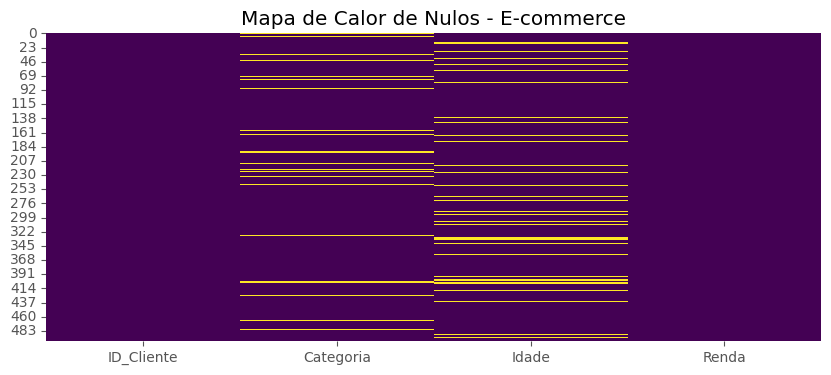


Ticket Médio (Renda) por Categoria:
Categoria
Casa           4092.25
Eletrônicos    3954.21
Livros         4059.61
Moda           4051.29
Name: Renda, dtype: float64


In [9]:
# RESOLUÇÃO
# 1. Carregar o CSV (sep e encoding corretos)
df_messy = pd.read_csv('ecommerce_messy.csv', sep=';', encoding='latin-1')

# 2. Remover duplicatas
print(f"Duplicatas: {df_messy.duplicated().sum()}")
df_messy.drop_duplicates(inplace=True)

# 3. Otimização de tipo (category)
df_messy['Categoria'] = df_messy['Categoria'].astype('category')

# 4. Heatmap de nulos
plt.figure(figsize=(10, 4))
sns.heatmap(df_messy.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de Calor de Nulos - E-commerce')
plt.show()

# 5. Imputação univariada (mediana p/ numérico, moda p/ categórico)
df_messy['Idade'].fillna(df_messy['Idade'].median(), inplace=True)
df_messy['Categoria'].fillna(df_messy['Categoria'].mode()[0], inplace=True)

# 6. Análise agrupada: Ticket Médio (Renda) por Categoria
print("\nTicket Médio (Renda) por Categoria:")
print(df_messy.groupby('Categoria', observed=True)['Renda'].mean().round(2))


---
## Parte 5: Desafio Final - Sobreviventes do Titanic (KNNImputer)
Para fixar o conhecimento de imputação multivariada vamos usar o famoso dataset do Titanic, embutido na biblioteca Seaborn.
O problema crônico desse dataset é a coluna `age` (idade), que possui dezenas de valores nulos. Usar apenas a média geral distorce a realidade: passageiros da 1ª classe tendiam a ser mais velhos que os da 3ª classe, e pessoas que viajavam sozinhas tinham idades diferentes das que viajavam em grandes famílias.

**Sua Missão:**
1. Isolar um sub-dataset apenas com características numéricas relevantes: `survived`, `pclass`, `age`, `sibsp` (Irmãos/Cônjuges), `parch` (Pais/Filhos) e `fare` (Tarifa).
2. Instanciar o `KNNImputer` e treinar neste sub-dataset para preencher as idades.
3. Recriar o DataFrame e confirmar que não existem mais nulos na variável `age` usando `.info()` ou `.isna().sum()`.

In [10]:
# NÃO ALTERE ESTE CÓDIGO - Carga do dataset Titanic (embutido no Seaborn)
df_titanic = sns.load_dataset('titanic')
print(f"Shape: {df_titanic.shape}")
print(f"Nulos na coluna 'age': {df_titanic['age'].isna().sum()}")
df_titanic.head()


Shape: (891, 15)
Nulos na coluna 'age': 177


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [11]:
# RESOLUÇÃO
from sklearn.impute import KNNImputer

# Passo 1: sub-dataset numérico relevante
colunas_alvo = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
df_titanic_num = df_titanic[colunas_alvo]

# Passo 2: instanciar
imputer = KNNImputer(n_neighbors=5)

# Passo 3: fit_transform
df_titanic_imputed_numpy = imputer.fit_transform(df_titanic_num)

# Passo 4: recriar DataFrame
df_titanic_tratado = pd.DataFrame(df_titanic_imputed_numpy, columns=df_titanic_num.columns)

# Passo 5: validar
print("Nulos após KNNImputer no Titanic:")
print(df_titanic_tratado.isna().sum())


Nulos após KNNImputer no Titanic:
survived    0
pclass      0
age         0
sibsp       0
parch       0
fare        0
dtype: int64
